In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np
# from matplotlib import style
# style.available

# Uchuu1000-Pl18

## wp

In [2]:
import sys
sys.path.append('../')
from CEmulator.Emulator import GalaxyEmulator

Omegam = 0.3111
OmegaL = 0.6889
h      = 0.6766
sigma8 = 0.8102 
Omegab = 0.0490 
ns     = 0.9665
mnu    = 0.0
Omegan = mnu/93.14/h/h
Omegac = Omegam - Omegab - Omegan
w0     = -1
wa     = 0
redshift = 0.49

# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=True)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)
# Set HOD parameters (Zheng+2005 model)
print("\nSetting HOD parameters...")
param_dict = {'logMcut': 12.88504333, 
              'logM1': 13.89309923, 
              'sigma': 0.21378519, 
              'alpha': 0.99114528, 
              'kappa': 0.5, 
              'fic': 1.0}
emu.set_hod(
    model_name='Zheng07',
    logMcut=param_dict['logMcut'], 
    logM1=param_dict['logM1'], 
    sigma=param_dict['sigma'], 
    alpha=param_dict['alpha'], 
    kappa=param_dict['kappa']
)
emu._galaxy_calc.satellite_profile.profile_type = "xihm"
# Compute galaxy properties at z=0.5
z = redshift
print(f"\nGalaxy properties at z={z}:")
print(f"  n_gal    = {emu.ngal(z):.4e} h^3/Mpc^3")
print(f"  f_sat    = {emu.f_sat(z):.3f}")
print(f"  M_eff    = {emu.M_eff(z):.3e} Msun/h")
print(f"  bias_gal = {emu.bias_gal(z):.3f}")

rbins  = np.logspace(-1, np.log10(50), 16)
rmid   = (rbins[1:] + rbins[:-1]) / 2

%time wp_emu = emu.wp(rp=rmid, z=z, pimax=100.0)

Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the ximm_cb emulator...
Using 129 training samples.
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the Bk_lin emulator...
Using 129 training samples.
Loading the Bk_halofit emulator...
Using 129 training samples.
Loading the lgBk_lin2hmcode2020 emulator...
Using 513 training samples.
Loading the Bk_hmcode2020 emulator...
Using 129 training samples.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
U

In [3]:
emu.get_hod_summary(z)

{'ngal': 0.000712364001904164,
 'f_sat': 0.17747685262328447,
 'M_eff': 30291165675198.668,
 'bias': 1.8616668632574358,
 'hod_params': {'logMcut': 12.88504333,
  'logM1': 13.89309923,
  'sigma': 0.21378519,
  'alpha': 0.99114528,
  'kappa': 0.5},
 'hod_model': 'Zheng07'}

In [4]:
import sys
sys.path.append('../')
from CEmulator.Emulator import GalaxyEmulator

# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=False)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)
emu.set_hod(
    model_name='Zheng07',
    logMcut=param_dict['logMcut'], 
    logM1=param_dict['logM1'], 
    sigma=param_dict['sigma'], 
    alpha=param_dict['alpha'], 
    kappa=param_dict['kappa']
)
emu._galaxy_calc.satellite_profile.profile_type = "nfw"
# Compute galaxy properties at z=0.5
z = redshift
print(f"\nGalaxy properties at z={z}:")
print(f"  n_gal    = {emu.ngal(z):.4e} h^3/Mpc^3")
print(f"  f_sat    = {emu.f_sat(z):.3f}")
print(f"  M_eff    = {emu.M_eff(z):.3e} Msun/h")
print(f"  bias_gal = {emu.bias_gal(z):.3f}")

rbins  = np.logspace(-1, np.log10(50), 16)
rmid   = (rbins[1:] + rbins[:-1]) / 2

%time wp_emu2 = emu.wp(rp=rmid, z=z, pimax=100.0)


Galaxy properties at z=0.49:
  n_gal    = 7.1236e-04 h^3/Mpc^3
  f_sat    = 0.177
  M_eff    = 3.029e+13 Msun/h
  bias_gal = 1.862
CPU times: user 144 ms, sys: 28.2 ms, total: 173 ms
Wall time: 173 ms


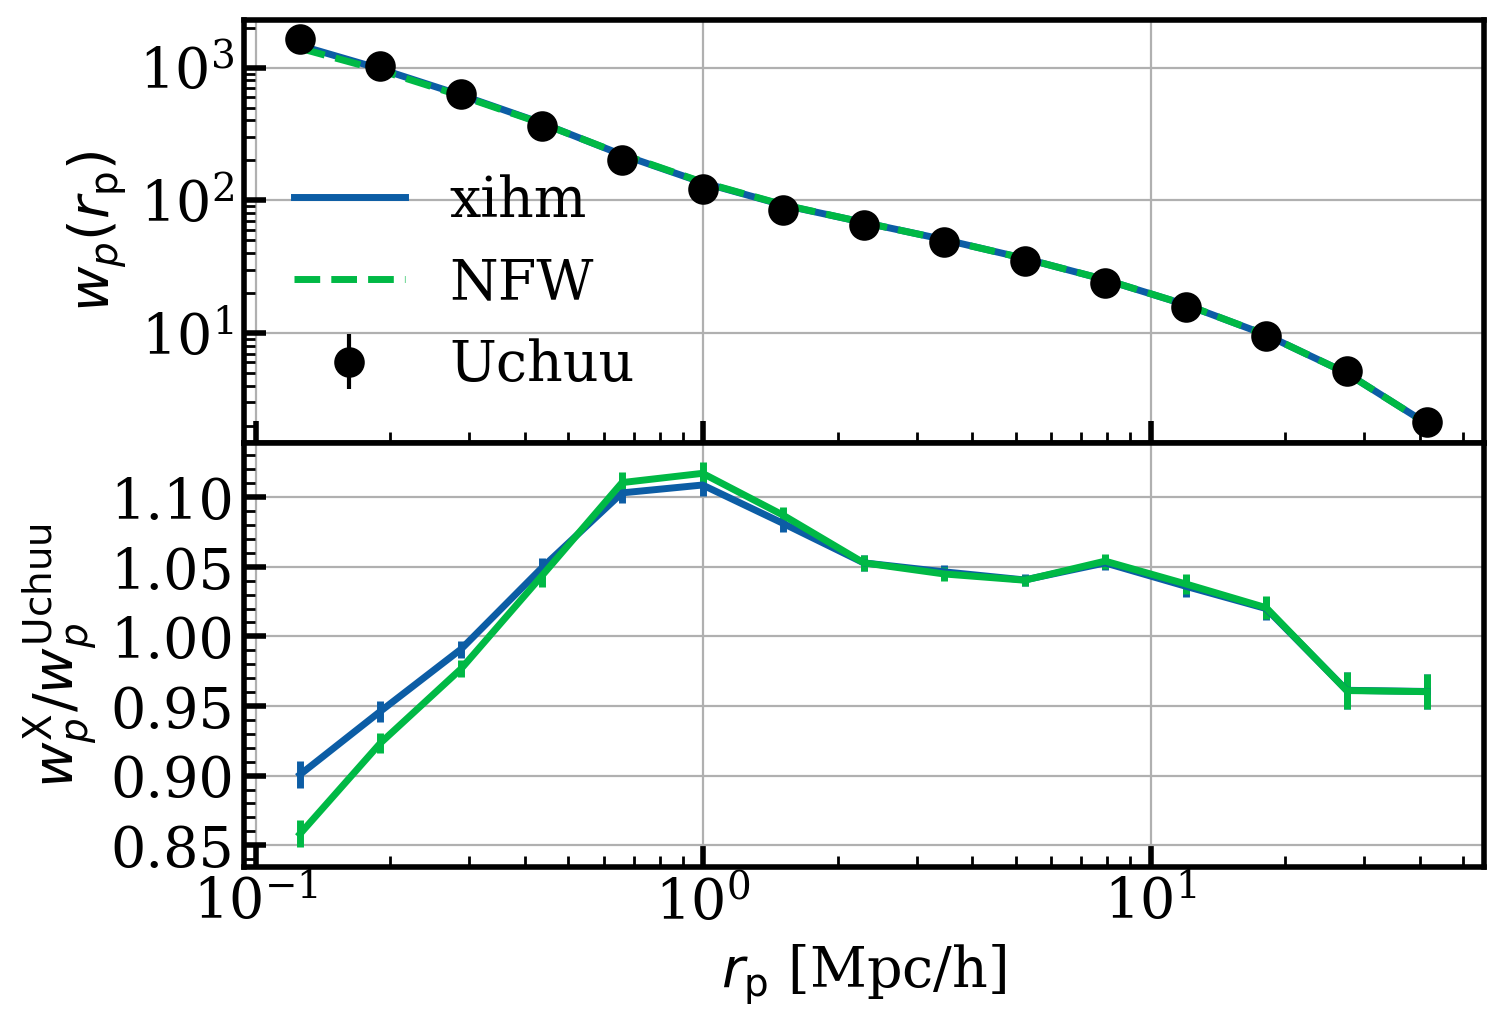

In [5]:
wp_rlz = np.zeros((16, 15))
for iseed in range(16):
    wp_rlz[iseed] = np.load("/Users/chenzhao/Desktop/mocktest/wp-galaxy-Uchuu1000-P18-1e12-Zheng07+fic-hod2-norsd-seed%d.npy"%(iseed))
std_wp  = np.std (wp_rlz, axis=0)
mean_wp = np.mean(wp_rlz, axis=0)

with plt.style.context("mypresentation"):
    gridp = plt.GridSpec(2, 1, wspace=0.0, hspace=0.0)
    plt.subplot(gridp[0])
    plt.plot(rmid, wp_emu, label="xihm")
    plt.plot(rmid, wp_emu2, '--', label ="NFW")
    plt.errorbar(rmid, mean_wp, std_wp, lw=1.5, fmt='ko', label='Uchuu')
    plt.legend()
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(r"$w_p(r_\mathrm{p})$")
    plt.gca().set_xticklabels([])
    plt.subplot(gridp[1])
    plt.errorbar(rmid, wp_emu /mean_wp, std_wp/mean_wp, label="xihm")
    plt.errorbar(rmid, wp_emu2/mean_wp, std_wp/mean_wp, label="NFW")
    plt.grid(True)
    plt.xscale('log') 
    # plt.ylim([0.975, 1.025])
    plt.xlabel(r"$r_\mathrm{p}$ [Mpc/h]")
    plt.ylabel(r"$w_p^\mathrm{X}/w_p^\mathrm{Uchuu}$")

### check components

(0.0001, 5000.0)

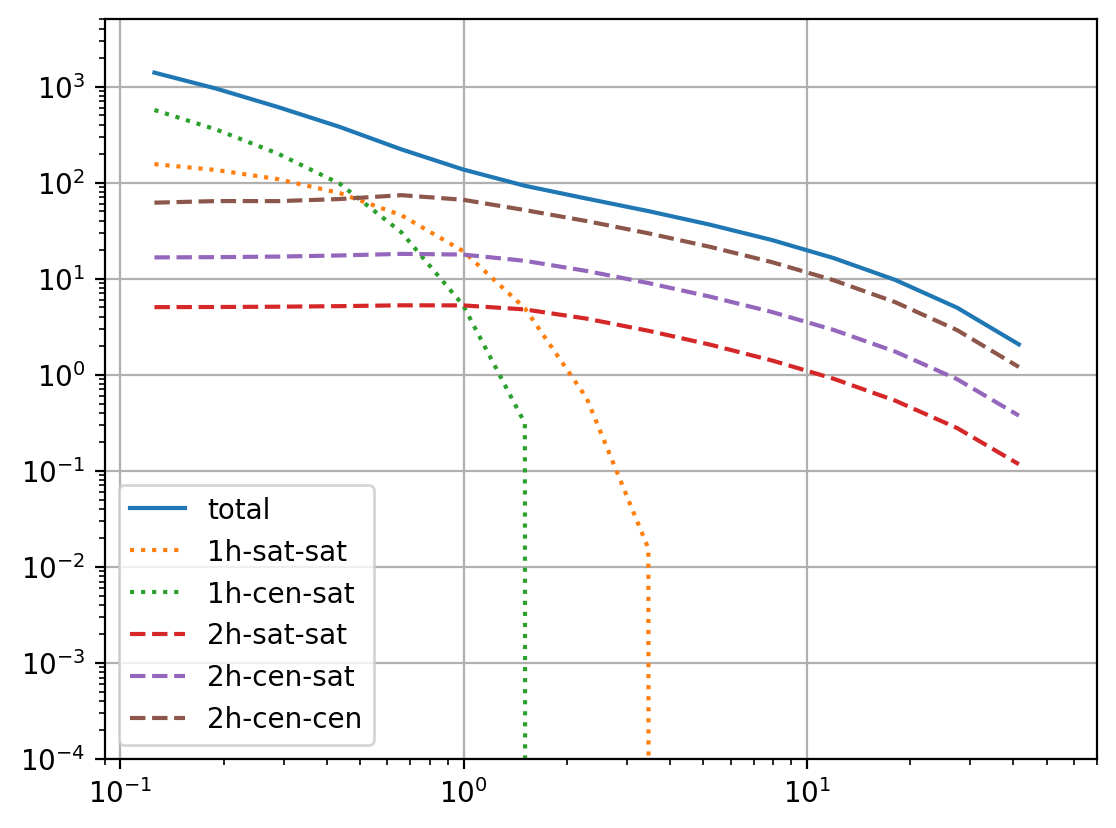

In [6]:
wp = emu.wp(rp=rmid, z=z)
wp_cs_1h = emu.wp_cs_1h(rmid, z)
wp_ss_1h = emu.wp_ss_1h(rmid, z)
wp_cs_2h = emu.wp_cs_2h(rmid, z)
wp_ss_2h = emu.wp_ss_2h(rmid, z)
wp_cc_2h = emu.wp_cc_2h(rmid, z)


plt.plot(rmid, wp, label="total")
plt.plot(rmid, wp_ss_1h, ":" , label="1h-sat-sat")
plt.plot(rmid, wp_cs_1h, ":" , label="1h-cen-sat")
plt.plot(rmid, wp_ss_2h, "--", label="2h-sat-sat")
plt.plot(rmid, wp_cs_2h, "--", label="2h-cen-sat")
plt.plot(rmid, wp_cc_2h, "--", label="2h-cen-cen")
# plt.plot(rmid, wp_sim, "ko", label="simulation")
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.xlim([9e-2, 70])
plt.ylim([1e-4, 5e3])

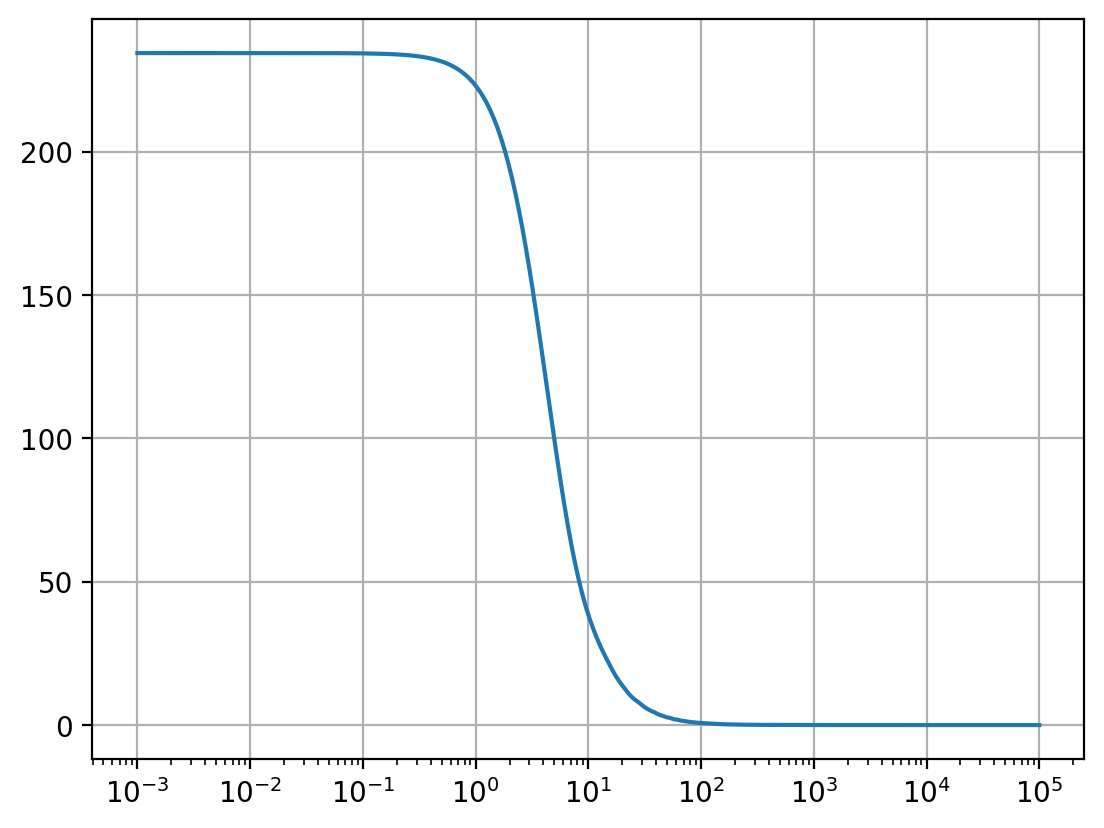

In [7]:
k_fft = emu._galaxy_calc.fftbase.k

p_1hcs = emu._galaxy_calc.compute_Pcs_1h(k_fft, z, emu._hod_model, **emu._hod_params)
plt.plot(k_fft, p_1hcs)
plt.xscale("log")
plt.grid(True)
# plt.ylim([-1, 350])

(0.0001, 2000.0)

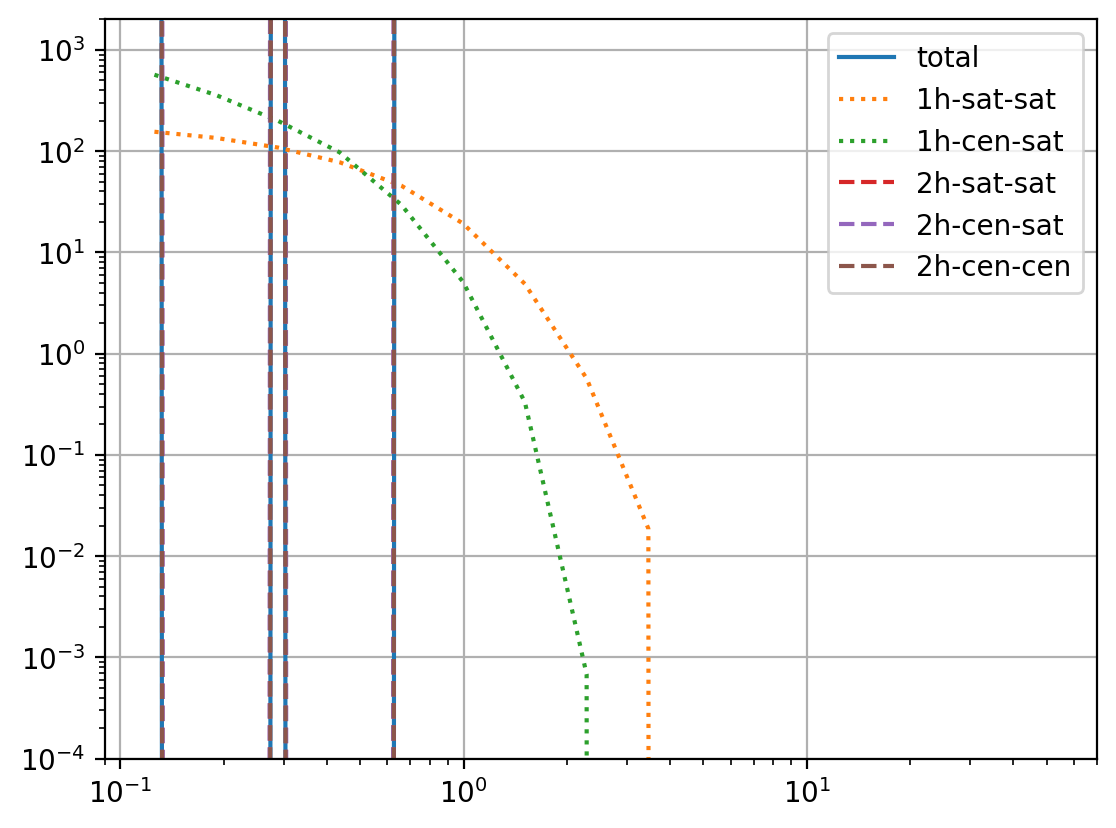

In [13]:
wp2_cs_1h = emu.wp_cs_1h(rmid, z)
wp2_ss_1h = emu.wp_ss_1h(rmid, z)
wp2_ss_2h = emu.wp_ss_2h(rmid, z)
wp2_cs_2h = emu.wp_cs_2h(rmid, z)
wp2_cc_2h = emu.wp_cc_2h(rmid, z)

# plt.plot(rmid, wp_emu)
plt.plot(rmid, wp_emu2, label='total')
plt.plot(rmid, wp2_ss_1h, ":" , label="1h-sat-sat")
plt.plot(rmid, wp2_cs_1h, ":" , label="1h-cen-sat")
plt.plot(rmid, wp2_ss_2h, "--", label="2h-sat-sat")
plt.plot(rmid, wp2_cs_2h, "--", label="2h-cen-sat")
plt.plot(rmid, wp2_cc_2h, "--", label="2h-cen-cen")
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.xlim([9e-2, 70])
plt.ylim([1e-4, 2e3])

[-2.3687347  -2.60516932 -3.6843982 ]
(33,)
Normalization factor: 2.8489e-02


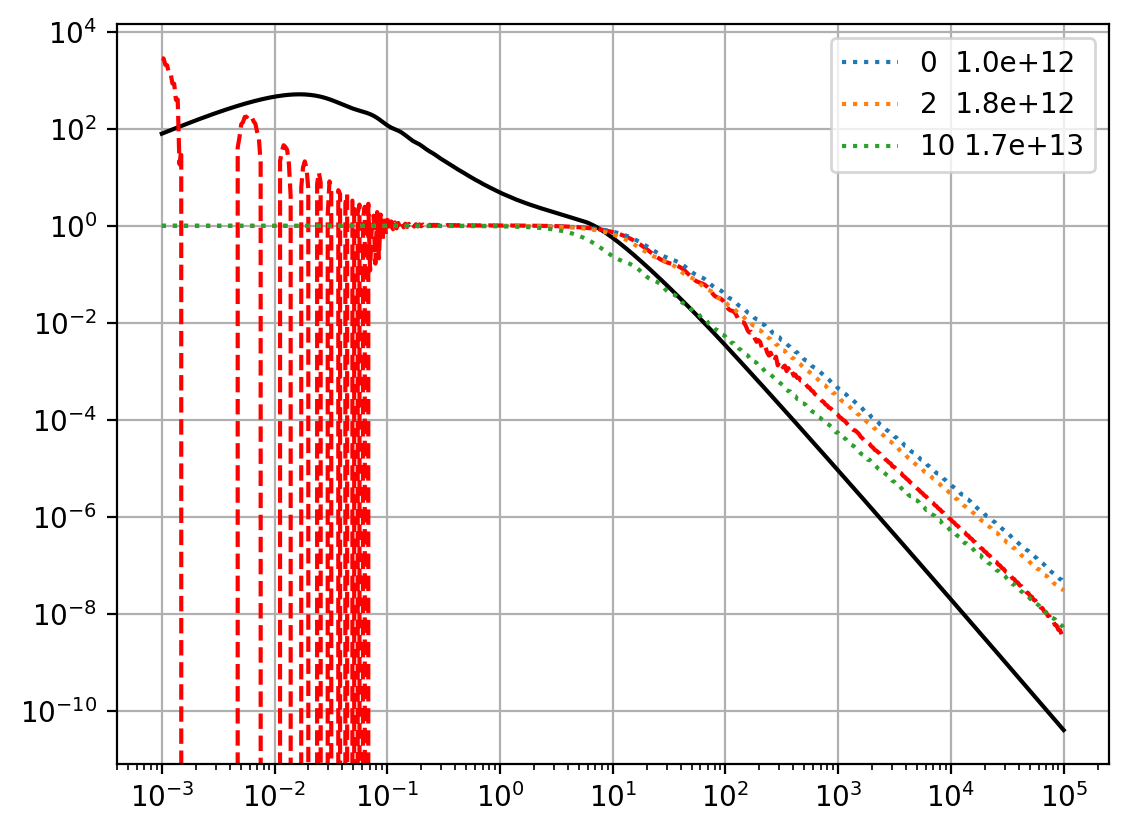

In [ ]:
from CEmulator.hankl import xi2P, galaxy
from scipy.integrate import simpson
im = 0

uk_grid = emu._galaxy_calc._uk_grid_cache[1]

r_fft = emu._galaxy_calc.fftbase.r
M_arr, lnM, dndlnM, lgden_arr, _ = emu._galaxy_calc._get_mass_for_fourier(z)
xi_hm_grid = emu._galaxy_calc._interp_xi_hm_for_masses(z, r_fft, lgden_arr)
print(lgden_arr[[0, 2, 10]])
rho_m = emu.Cosmo.rho_crit*emu.Cosmo.Omegam
# M_arr = emu._get_mass_from_lgden(redshift, lgden_arr)[0]
print(M_arr.shape)
R200  = (3.0 * M_arr[im] / (4.0 * np.pi * 200 * rho_m)) ** (1.0/3)
xi_trunc = np.copy(xi_hm_grid[im])
mask = r_fft > R200
xi_trunc[mask] = 0.0
k_conv, pkhm_conv = galaxy.xi2pk(r_fft, xi_trunc, 0, ext=0)
mask_r = r_fft <= R200
integrand = (4.0 * np.pi * r_fft[mask_r] ** 3 * rho_m
          * (1.0 + (xi_trunc[mask_r])))
norm = simpson(integrand, x=np.log(r_fft[mask_r]))
print(f"Normalization factor: {rho_m/norm:.4e}")
k_fft      = emu._galaxy_calc.fftbase.k
pkhm_grid  = emu.get_pkhm_lgnbar_threshold(redshift, k_fft, np.clip(lgden_arr[im], -5, -2.5))

plt.plot(k_fft,  pkhm_grid[0,0]*(rho_m/norm), 'k-')
plt.plot(k_conv, pkhm_conv*(rho_m/norm), 'r--')
plt.plot(k_fft, uk_grid[:,0 ], ':', label=r'0  %.1e'%(M_arr[0]))
plt.plot(k_fft, uk_grid[:,2 ], ':', label=r'2  %.1e'%(M_arr[2]))
plt.plot(k_fft, uk_grid[:,10], ':', label=r'10 %.1e'%(M_arr[10]))
plt.legend()
plt.xscale('log')
plt.yscale('log')
# plt.ylim([1e-10, 2.1])
plt.grid(True)

In [ ]:
Ncen, Nsat, _ = emu._galaxy_calc._get_cached_hod_weights(emu._hod_model, **emu._hod_params)

In [ ]:
Nsat/Ncen

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.10779315e-03, 2.05079840e-02, 4.33234948e-02,
       7.33650724e-02, 1.12971691e-01, 1.65221096e-01, 2.34173539e-01,
       3.25189078e-01, 4.45345355e-01, 6.03988858e-01, 8.13462760e-01,
       1.09006804e+00, 1.45533274e+00, 1.93768825e+00, 2.57468306e+00,
       3.41590640e+00, 4.52684948e+00, 5.99400479e+00, 7.93160077e+00,
       1.04904960e+01, 1.38699254e+01, 1.83330138e+01, 2.42272631e+01,
       3.20116105e+01, 4.22921625e+01, 5.58693887e+01, 7.38004490e+01,
       9.74815075e+01])

(1e-05, 200.0)

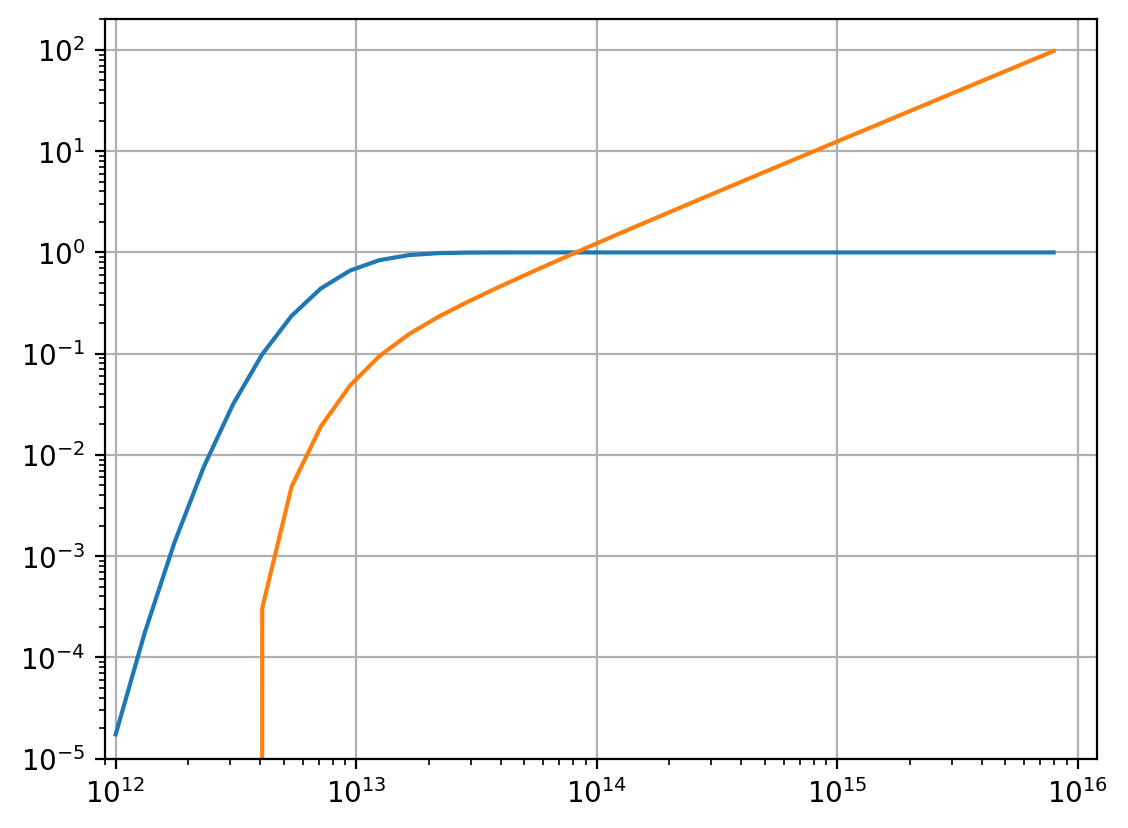

In [ ]:
Mh = emu._galaxy_calc.M_grid 
plt.plot(Mh, Ncen)
plt.plot(Mh, Nsat)
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.xlim([9e11, 1.2e16])
plt.ylim([1e-5, 2e2])

In [ ]:
# Compute galaxy-matter correlation
r = np.logspace(-2, 2.2, 200)  # 0.1 to ~30 Mpc/h

print(f"\nComputing galaxy-matter correlation at z={z}...")
%time Xigm = emu.Xigm(r, z)

print(f"Computing galaxy-galaxy correlation at z={z}...")
%time Xigg = emu.Xigg(r, z)

# Print some values
print(f"\nxi_gm(r=1 Mpc/h) = {Xigm[20]:.4f}")
print(f"xi_gg(r=1 Mpc/h) = {Xigg[20]:.4f}")


Computing galaxy-matter correlation at z=0.49...
CPU times: user 829 ms, sys: 10.1 ms, total: 839 ms
Wall time: 642 ms
Computing galaxy-galaxy correlation at z=0.49...
CPU times: user 3 ms, sys: 11 µs, total: 3.01 ms
Wall time: 937 µs

xi_gm(r=1 Mpc/h) = 14091.9491
xi_gg(r=1 Mpc/h) = 37057.7256


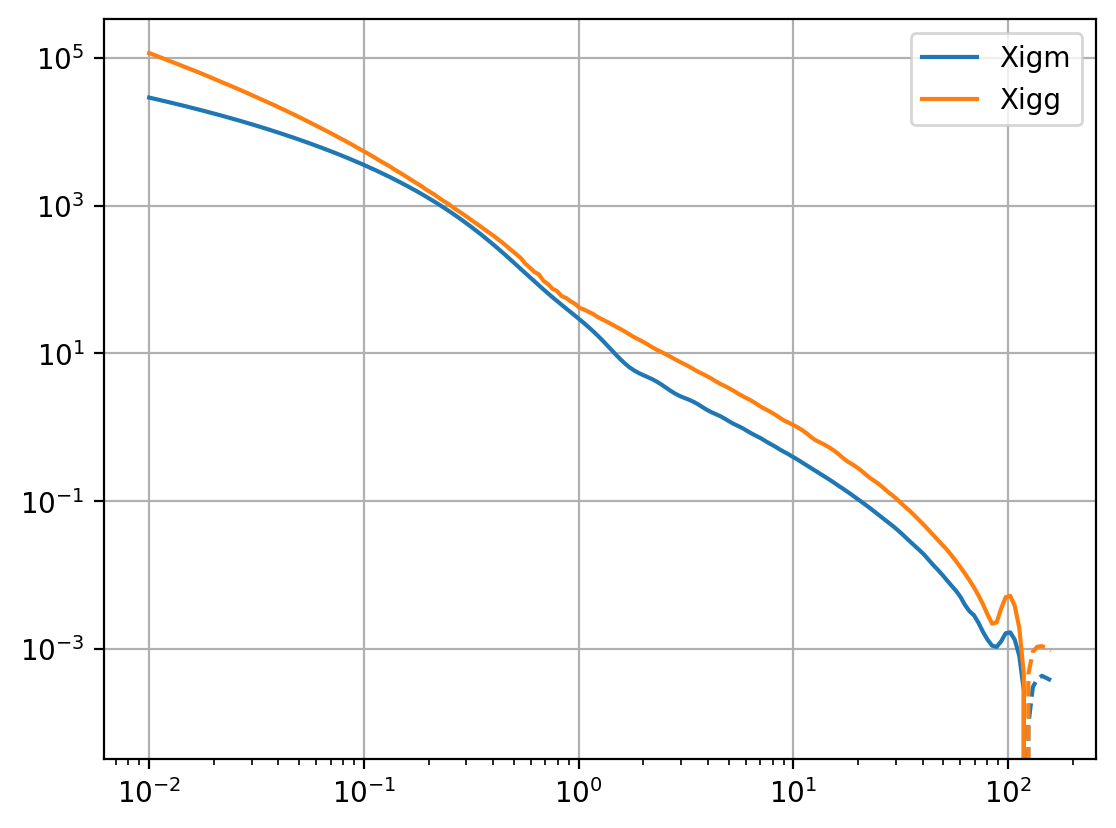

In [ ]:
l1, = plt.plot(r, Xigm, label="Xigm")
plt.plot(r, -Xigm, ls='--', color=l1.get_color())
l2, = plt.plot(r, Xigg, label="Xigg")
plt.plot(r, -Xigg, ls='--', color=l2.get_color())
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.grid(True)

## Galaxy-Galaxy Lensing
Compute  (projected galaxy-matter correlation) and  (excess surface density) using the public GalaxyEmulator API.


In [8]:
# Re-initialize with fresh emulator
# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=False)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)
emu.set_hod(
    model_name='Zheng07',
    logMcut=param_dict['logMcut'], 
    logM1=param_dict['logM1'], 
    sigma=param_dict['sigma'], 
    alpha=param_dict['alpha'], 
    kappa=param_dict['kappa']
)
emu._galaxy_calc.satellite_profile.profile_type = "xihm"
%time ds_emu  = emu.DeltaSigma(rmid, z)

CPU times: user 529 ms, sys: 5.42 ms, total: 535 ms
Wall time: 537 ms


In [9]:
# Re-initialize with fresh emulator
# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=False)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)
emu.set_hod(
    model_name='Zheng07',
    logMcut=param_dict['logMcut'], 
    logM1=param_dict['logM1'], 
    sigma=param_dict['sigma'], 
    alpha=param_dict['alpha'], 
    kappa=param_dict['kappa']
)
emu._galaxy_calc.satellite_profile.profile_type = "nfw"
%time ds_emu2  = emu.DeltaSigma(rmid, z)

CPU times: user 515 ms, sys: 5.62 ms, total: 520 ms
Wall time: 524 ms


In [10]:
ds_rlz = np.zeros((16, 15))
for iseed in range(16):
    ds_rlz[iseed] = np.load("/Users/chenzhao/Desktop/mocktest/ds-galaxy-Uchuu1000-P18-1e12-Zheng07+fic-hod2-seed%d.npy"%(iseed))
std_ds  = np.std (ds_rlz, axis=0)
mean_ds = np.mean(ds_rlz, axis=0)

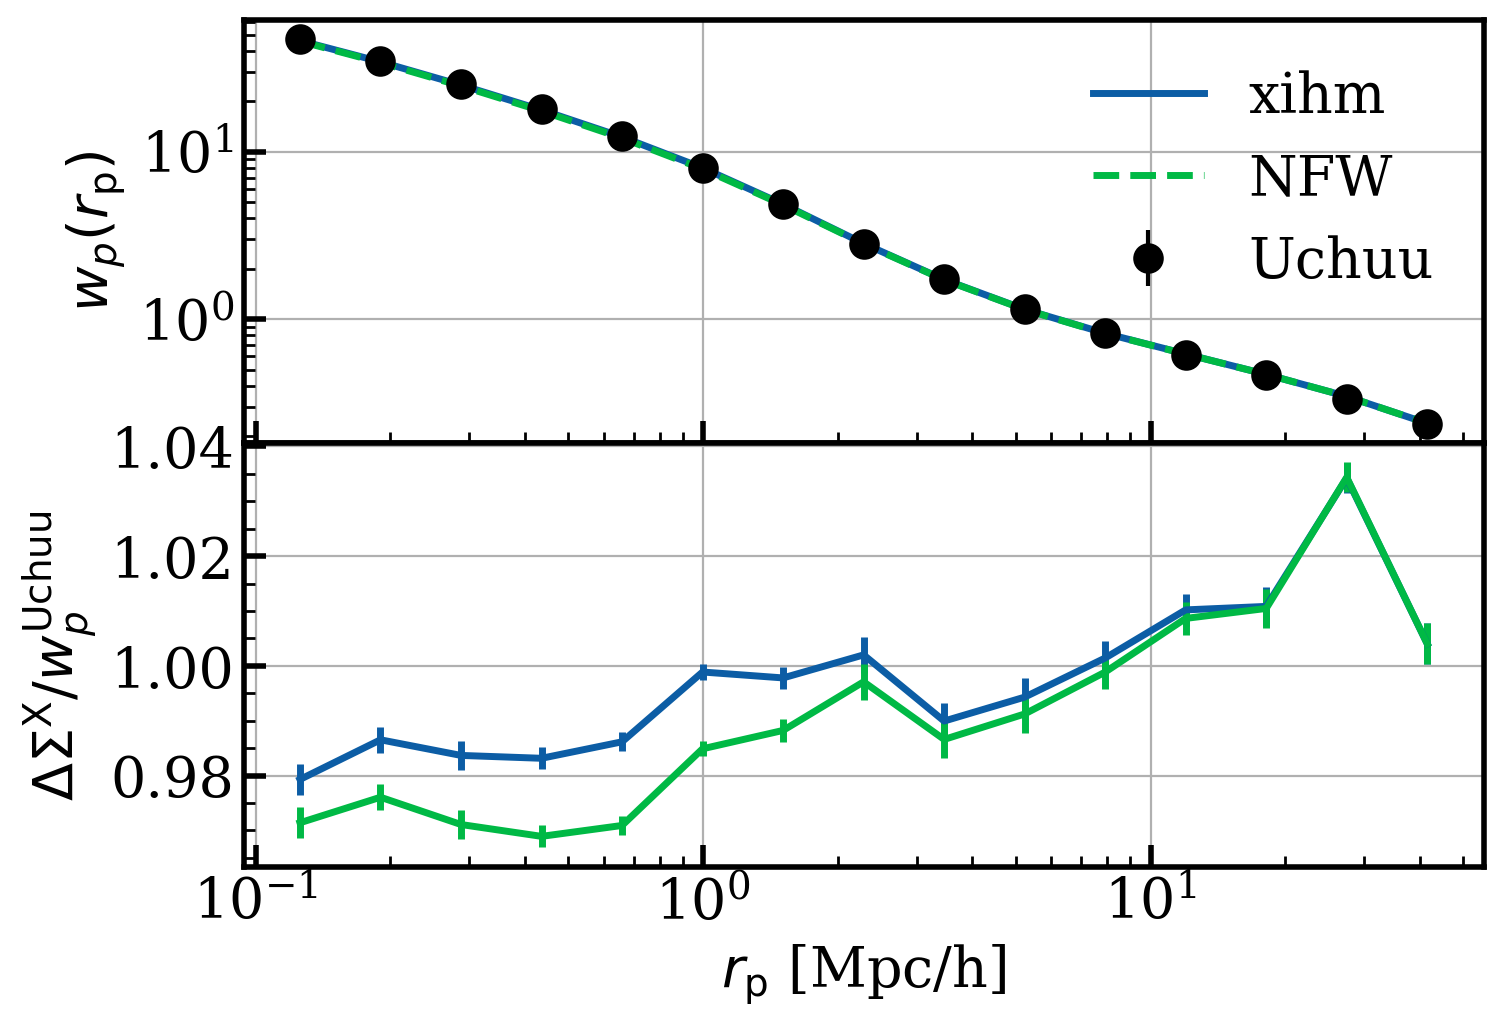

In [11]:
with plt.style.context("mypresentation"):
    gridp = plt.GridSpec(2, 1, wspace=0.0, hspace=0.0)
    plt.subplot(gridp[0])
    plt.plot(rmid, ds_emu, label="xihm")
    plt.plot(rmid, ds_emu2, '--', label ="NFW")
    plt.errorbar(rmid, mean_ds, std_ds, lw=1.5, fmt='ko', label='Uchuu')
    plt.legend()
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(r"$w_p(r_\mathrm{p})$")
    plt.gca().set_xticklabels([])
    plt.subplot(gridp[1])
    plt.errorbar(rmid, ds_emu /mean_ds, std_ds/mean_ds, label="xihm")
    plt.errorbar(rmid, ds_emu2/mean_ds, std_ds/mean_ds, label="NFW")
    plt.grid(True)
    plt.xscale('log') 
    # plt.ylim([0.975, 1.025])
    plt.xlabel(r"$r_\mathrm{p}$ [Mpc/h]")
    plt.ylabel(r"$\Delta\Sigma^\mathrm{X}/w_p^\mathrm{Uchuu}$")

/Users/chenzhao/Desktop/work/softwares/csstemu/examples/../CEmulator/hankl/preprocess.py:184: RuntimeWarning: invalid value encountered in scalar divide
  f_right = f[-1] * (f[-1] / f[-2]) ** np.arange(1, N_right + 1)


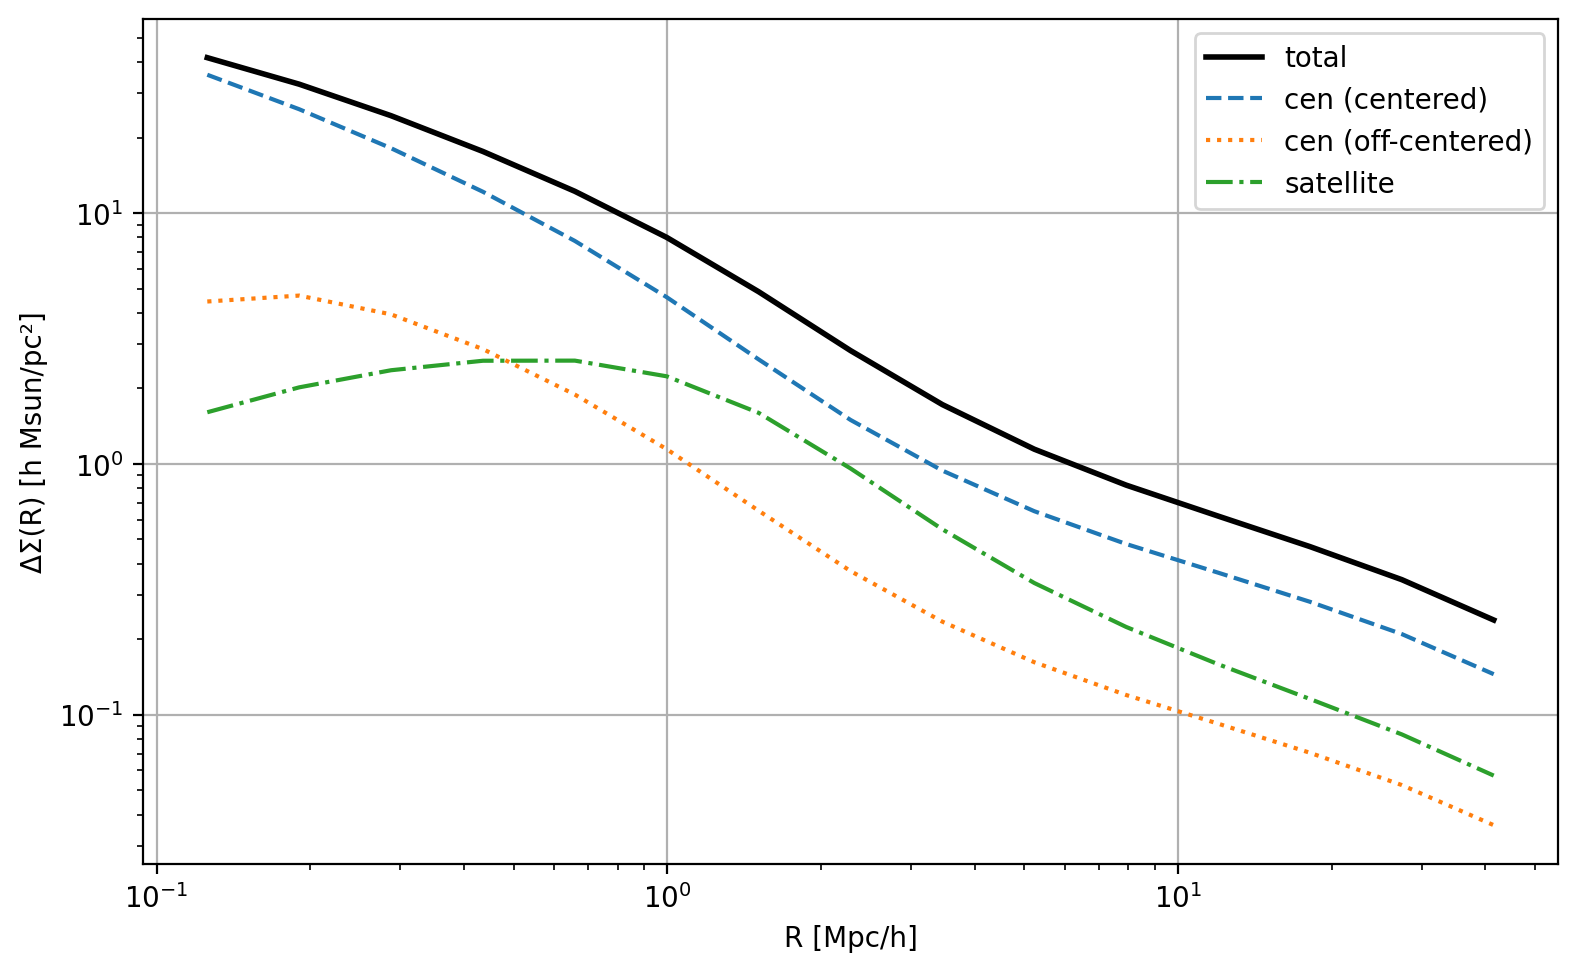

✓ Component sum matches total ΔΣ


In [15]:
emu.set_hod(
    model_name='Zheng07',
    logMcut=param_dict['logMcut'], 
    logM1=param_dict['logM1'], 
    sigma=param_dict['sigma'], 
    alpha=param_dict['alpha'], 
    kappa=param_dict['kappa'],
    f_off=0.2,
    R_off=0.1,
)
ds  = emu.DeltaSigma(rmid, z)
ds_cen, ds_off, ds_sat = emu.DeltaSigma_components(rmid, z)

plt.figure(figsize=(8, 5))
plt.loglog(rmid, ds, 'k-', lw=2, label="total")
plt.loglog(rmid, ds_cen, '--', label="cen (centered)")
plt.loglog(rmid, ds_off, ':', label="cen (off-centered)")
plt.loglog(rmid, ds_sat, '-.', label="satellite")
plt.xlabel("R [Mpc/h]")
plt.ylabel("ΔΣ(R) [h Msun/pc²]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Check sum matches
np.testing.assert_allclose(ds, ds_cen + ds_off + ds_sat, rtol=1e-6)
print("✓ Component sum matches total ΔΣ")

## halo statistics 

In [16]:
import sys
sys.path.append('../')
from CEmulator.Emulator import GalaxyEmulator

Omegam = 0.3111
OmegaL = 0.6889
h      = 0.6766
sigma8 = 0.8102 
Omegab = 0.0490 
ns     = 0.9665
mnu    = 0.0
Omegan = mnu/93.14/h/h
Omegac = Omegam - Omegab - Omegan
w0     = -1
wa     = 0
redshift = 0.49

# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=True)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)


Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the ximm_cb emulator...
Using 129 training samples.
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the Bk_lin emulator...
Using 129 training samples.
Loading the Bk_halofit emulator...
Using 129 training samples.
Loading the lgBk_lin2hmcode2020 emulator...
Using 513 training samples.
Loading the Bk_hmcode2020 emulator...
Using 129 training samples.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
U

In [17]:
m_edges = np.logspace(10, 16, 60+1)
dlgM    = np.log10(m_edges[1]) - np.log10(m_edges[0])
dlnM    = np.log(m_edges[1]) - np.log(m_edges[0])
mcen    = 10**((np.log10(m_edges[1:]) + np.log10(m_edges[:-1]))/2)
zlists  = np.array([redshift])
%time dndlnM_200m  = emu.get_dndlnM(z=zlists, M=mcen, massdef='RockstarM200m')
dndlnM_simu = np.loadtxt("/Users/chenzhao/Desktop/mocktest/hmf_Uchuu1000-Pl18_Nbin60_z0p49.txt")[:,1] / dlnM / 1e9


CPU times: user 563 ms, sys: 7.14 ms, total: 570 ms
Wall time: 578 ms


/var/folders/01/fk0gr9r91yq1bjz_5vw1g0y40000gn/T/ipykernel_3534/1633395594.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(mcen, dndlnM_200m[0]/dndlnM_simu)
/var/folders/01/fk0gr9r91yq1bjz_5vw1g0y40000gn/T/ipykernel_3534/1633395594.py:6: RuntimeWarning: divide by zero encountered in divide
  err = 1/np.sqrt(dndlnM_simu*dlnM*1e9)


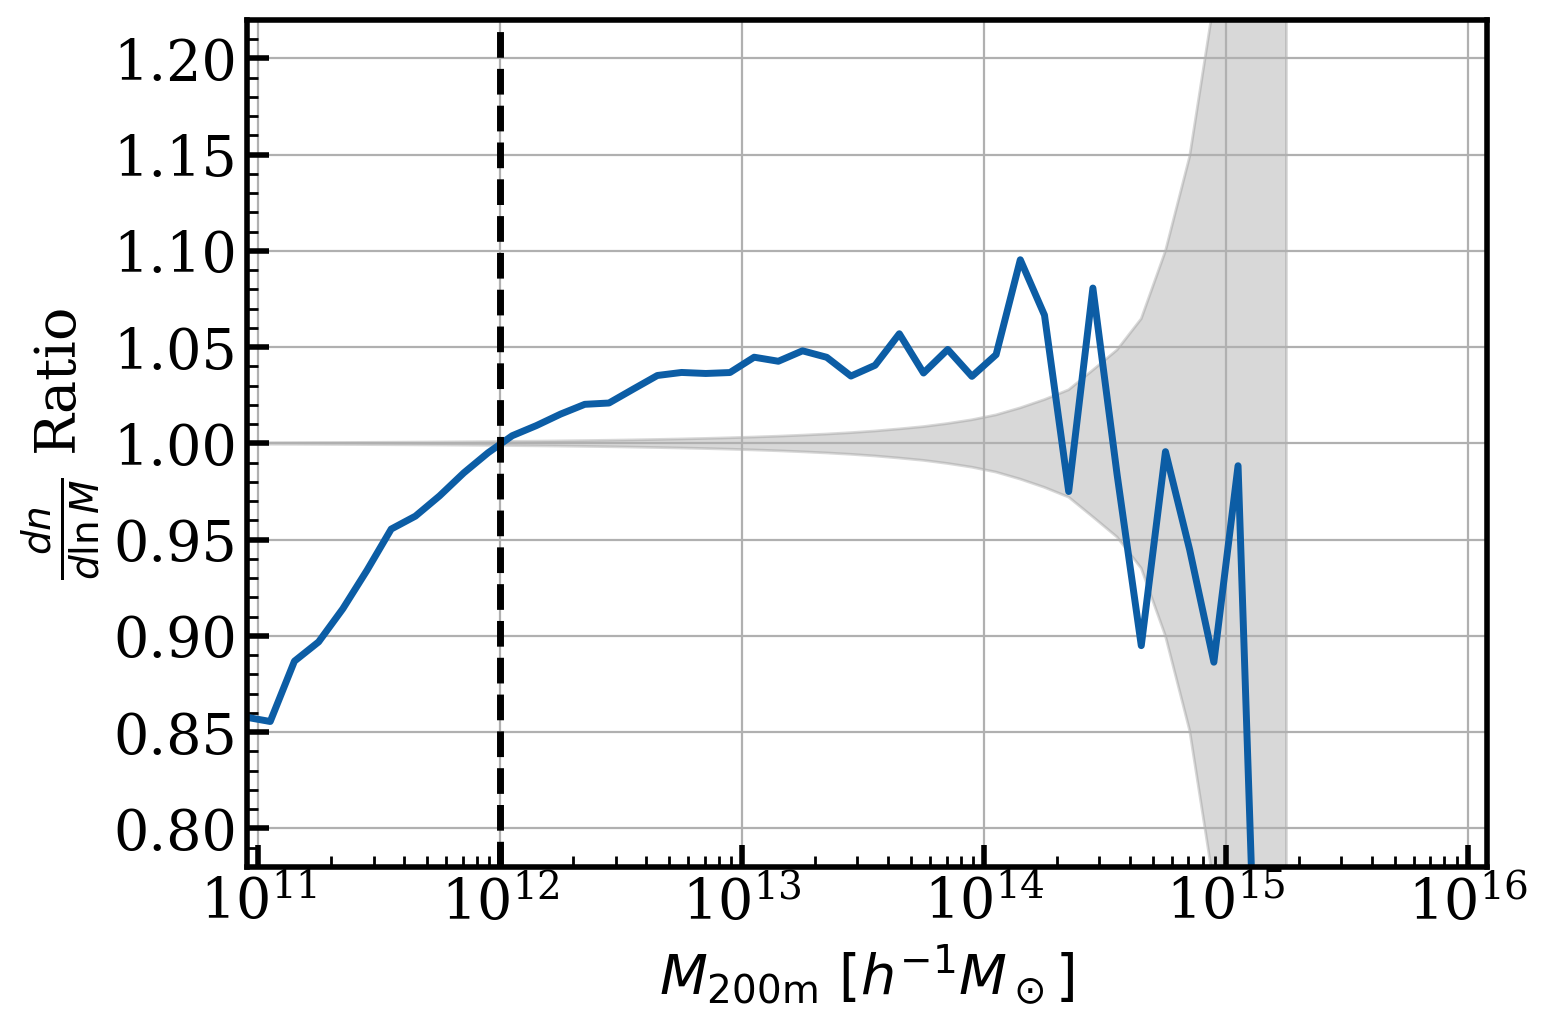

In [18]:
with plt.style.context('mypresentation'):
    plt.plot(mcen, dndlnM_200m[0]/dndlnM_simu)
    plt.xscale('log')
    plt.xlim([9e10, 1.2e16])
    plt.axvline(1e12, color='k', ls='--', label=r'$10^{12} M_\odot/h$')
    err = 1/np.sqrt(dndlnM_simu*dlnM*1e9)
    plt.fill_between(mcen, 1-err, 1+err, color='gray', alpha=0.3, label=r'$\pm 1/\sqrt{N}$')
    plt.ylim(0.78, 1.22)
    plt.xlabel(r"$M_{\rm %s}\ [h^{-1}M_\odot]$"%("200m"))
    plt.ylabel(r"$\frac{dn}{d\ln M}$ Ratio")

In [19]:
rbins = np.concatenate([np.logspace(-2, 1, 30+1)[:-1],
                                np.arange(10, 500, 5)])
rmid  = (rbins[1:] + rbins[:-1]) / 2

xihh_sim = np.loadtxt("/Users/chenzhao/Desktop/mocktest/xihh_allN_z0p49_HybridNbin127_Uchuu1000-Pl18.txt")
print(xihh_sim.shape)

dencutlist = np.logspace(-8.5, -2.5, 13)
nden  = len(dencutlist)
nauto = (nden+1)*nden // 2
ind   = 0
lgdencut1 = np.zeros((nauto))
lgdencut2 = np.zeros((nauto))
for id1 in range(nden):
    for id2 in range(nden):
        if id1 <= id2:
            lgdencut1[ind] = np.log10(dencutlist[id1])
            lgdencut2[ind] = np.log10(dencutlist[id2])
            ind += 1
idenst = 7
ind1 = lgdencut1 >= np.log10(dencutlist[idenst])
ind2 = lgdencut2 >= np.log10(dencutlist[idenst]) 
ind_den = np.arange(nauto)[ind1 * ind2]

lgdens = np.linspace(-5.0, -2.5, 6) 
idenlist = []
i0 = 0
for ii in ind_den:
    if lgdencut1[ii] == lgdens[i0] and lgdencut2[ii] == lgdens[i0]:
        idenlist.append(ii)
        i0 += 1
print(idenlist)
print(lgdencut1[idenlist])
print(lgdencut2[idenlist])

lgdens = np.linspace(-5.0, -2.5, 6) 
xihh_emu = np.zeros((len(zlists), len(lgdens), len(rmid)))
for ii in range(len(lgdens)):
    xihh_emu[:,ii] = emu.Xihh.get_xihh_lgnbar_threshold(r=rmid, z=redshift, lgden1=lgdens[ii], lgden2=lgdens[ii])
print(xihh_emu.shape)

(127, 92)
[70, 76, 81, 85, 88, 90]
[-5.  -4.5 -4.  -3.5 -3.  -2.5]
[-5.  -4.5 -4.  -3.5 -3.  -2.5]
Loading Xihh emulator...
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir_bound emulator...
Using 129 training samples.
Loading the bhmNumBin_RockstarM200m emulator...
Using 129 training samples.
Loading the hNumBin_RockstarM200m emulator...
Using 129 training samples.
(1, 6, 127)


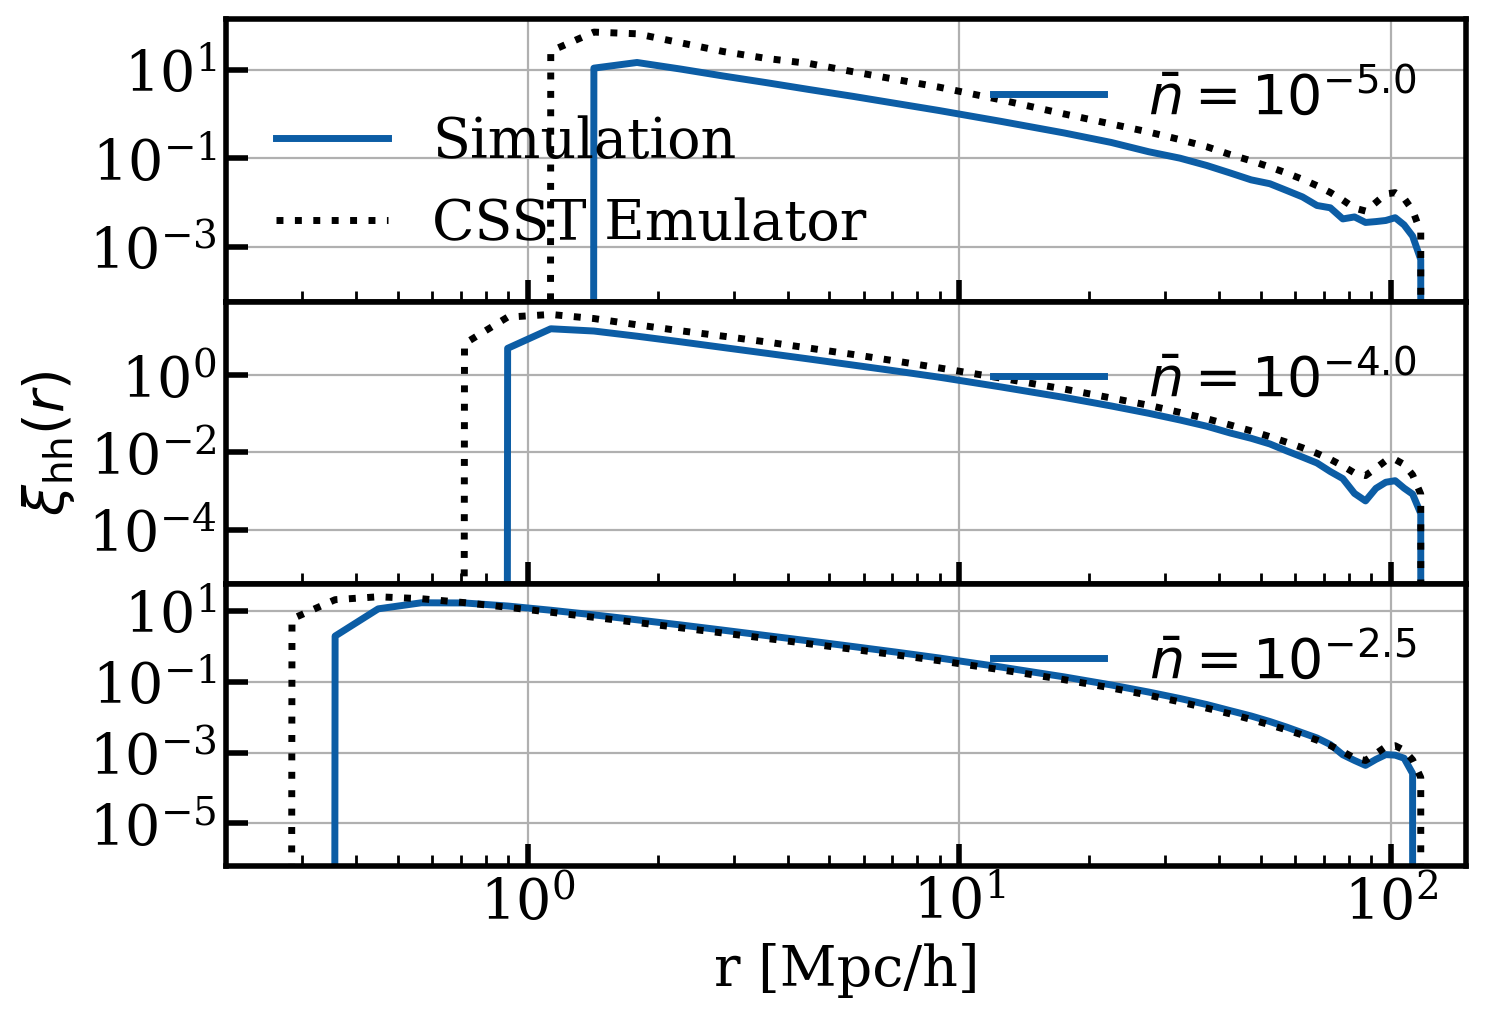

In [20]:
idensel = [0, 2, 5]
gridp   = plt.GridSpec(len(idensel), 1, wspace=0.0, hspace=0.0)
legstrs = [r"$\bar{n}=10^{%.1f}$"%(iden) for iden in lgdens]
with plt.style.context("mypresentation"):
    for pind, ii in enumerate(idensel):
        plt.subplot(gridp[pind])
        isim = idenlist[ii]
        l1, = plt.loglog(rmid,  xihh_sim[:,isim], ls='-', label=legstrs[ii])
        l2, = plt.loglog(rmid,  xihh_emu[0,ii], color='k', ls=":")
        leg1 = plt.legend(loc="upper right", ncol=1)
        if pind == 0:
            leg2 = plt.legend([l1,l2], ["Simulation", "CSST Emulator"], ncol=1)
            plt.gca().add_artist(leg1)
        # plt.ylim([0.8, 1.2])
        plt.xlim([2e-1, 150])
        plt.grid(True)
        if pind == len(idensel)-1:
            plt.xlabel("r [Mpc/h]")
        else:
            plt.gca().set_xticklabels([])
        if pind == 1:
            plt.ylabel(r"$\xi_{\rm hh}(r)$")
        

In [21]:
rbins = np.concatenate([np.logspace(-2, 1, 30+1)[:-1],
                                np.arange(10, 50, 5)])
rmid  = (rbins[1:] + rbins[:-1]) / 2

xihm_sim = np.loadtxt("/Users/chenzhao/Desktop/mocktest/xihm_allN_z0p49_samp0p015625_down1024_HybridNBin37_Uchuu1000-Pl18.txt")
print(xihm_sim.shape, len(rmid))

xihm_emu = emu.get_xihm_lgnbar_threshold(r=rmid, z=redshift, lgden=lgdens)
print(xihm_emu.shape)

(37, 14) 37
(6, 1, 37)


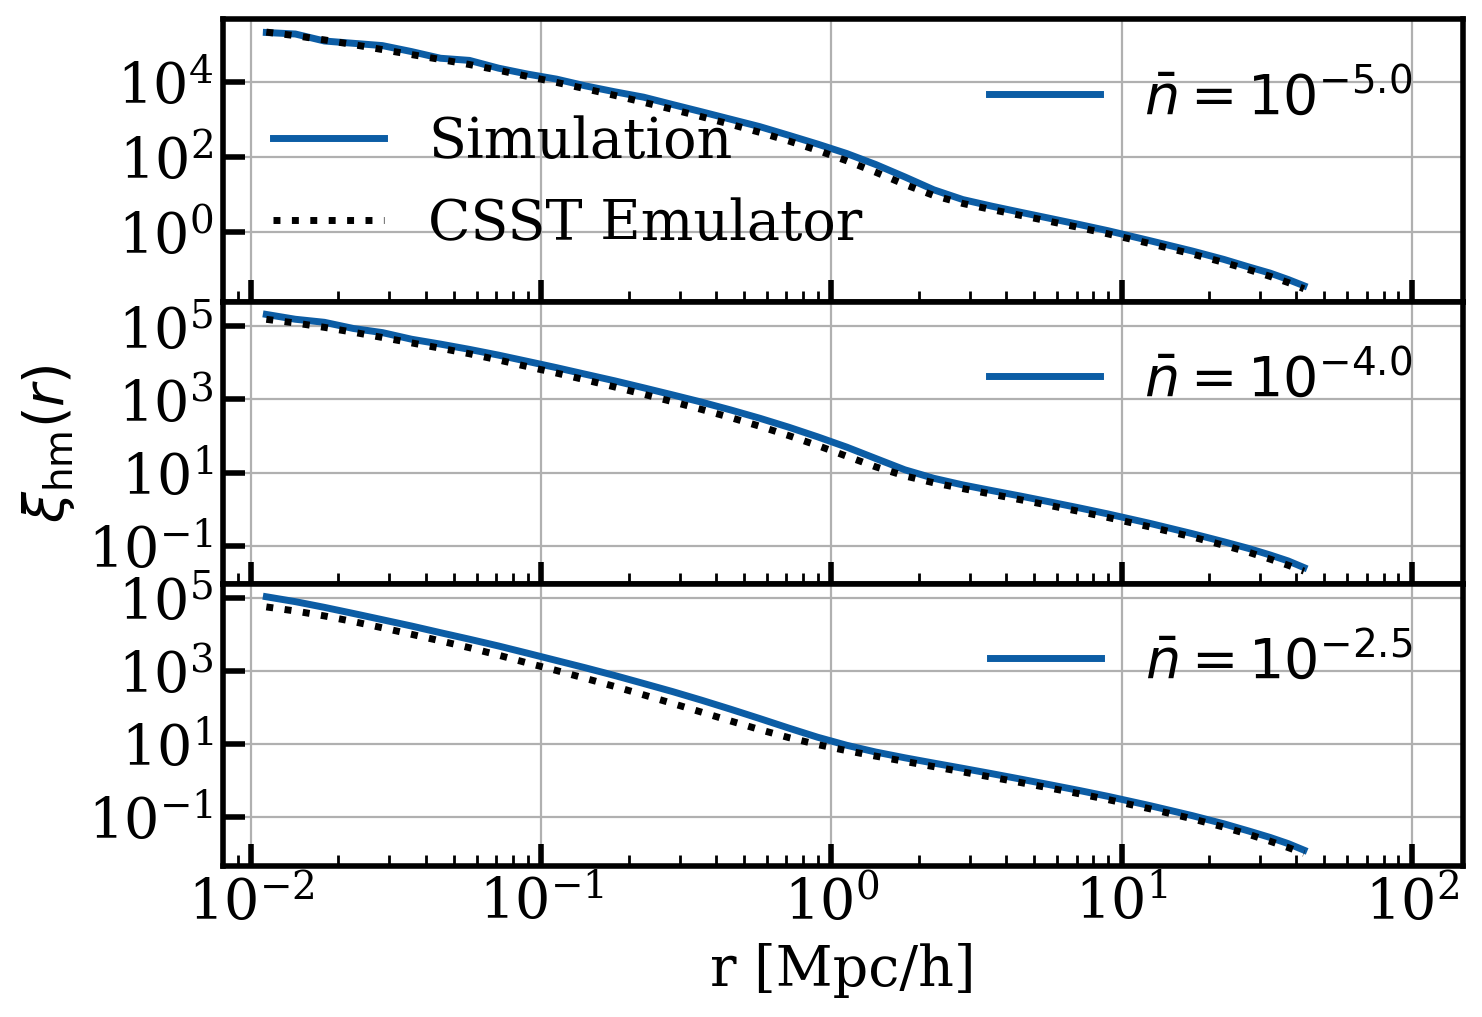

In [22]:
idensel = [0, 2, 5]
gridp   = plt.GridSpec(len(idensel), 1, wspace=0.0, hspace=0.0)
legstrs = [r"$\bar{n}=10^{%.1f}$"%(iden) for iden in lgdens]
with plt.style.context("mypresentation"):
    for pind, ii in enumerate(idensel):
        plt.subplot(gridp[pind])
        l1, = plt.loglog(rmid,  xihm_sim[:,7+ii], ls='-', label=legstrs[ii])
        l2, = plt.loglog(rmid,  xihm_emu[ii,0], color='k', ls=":")
        leg1 = plt.legend()
        if pind == 0:
            leg2 = plt.legend([l1,l2], ["Simulation", "CSST Emulator"])
            plt.gca().add_artist(leg1)
        # plt.ylim([0.8, 1.2])
        plt.grid(True)
        plt.xlim([8e-3, 150])
        if pind == len(idensel)-1:
            plt.xlabel("r [Mpc/h]")
        else:
            plt.gca().set_xticklabels([])
        if pind == 1:
            plt.ylabel(r"$\xi_{\rm hm}(r)$")
        